In [23]:
import pathlib, re, tifffile, numpy as np, pandas as pd

root = pathlib.Path(r"Z:\Bel\Farid_bel\Calcium experiment")

# Collect all TIFs, skip "no background" folders
tif_paths = [
    p for p in sorted(root.rglob("*.tif"))
    if "no background" not in str(p).lower()
    and "background_removed" not in str(p).lower()
]
print(f"Found {len(tif_paths)} TIF files\n")

# ── Extract a sort key from the filename time range ──────────────────────────
def _time_sort_key(path):
    """Extract numeric start-time from names like '0-10mins' or '10-20mins'."""
    m = re.search(r"(\d+)-\d+\s*mins?", path.stem, re.IGNORECASE)
    return int(m.group(1)) if m else 0

# ── Group by condition (parent folder) ───────────────────────────────────────
from collections import defaultdict
groups = defaultdict(list)
for p in tif_paths:
    # Use "date / folder" as condition key, e.g. "18.02.26 / Valve 2 3D"
    condition = f"{p.parent.parent.name} / {p.parent.name}"
    groups[condition].append(p)

# Sort each group by time
for condition in groups:
    groups[condition].sort(key=_time_sort_key)

# ── Process each group: sum all pixel intensities per timepoint ───────────────
rows = []
for condition, paths in sorted(groups.items()):
    print(f"── {condition} ({len(paths)} files) ──")
    global_t = 0
    for p in paths:
        data = tifffile.imread(str(p))  # (T, Z, Y, X)
        if data.ndim == 4:
            n_frames = data.shape[0]
        elif data.ndim == 3:
            n_frames = data.shape[0]
        else:
            print(f"  SKIP unexpected shape {data.shape}: {p.name}")
            continue

        for t in range(n_frames):
            rows.append({
                "condition": condition,
                "file": p.name,
                "timepoint": global_t,
                "sum_intensity": int(data[t].sum()),
            })
            global_t += 1
        print(f"  {p.name}  shape={data.shape}  frames={n_frames}")

df = pd.DataFrame(rows)

# ── Save CSV ─────────────────────────────────────────────────────────────────
out_csv = root / "sum_intensity_per_timepoint.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved {len(df)} rows to:\n  {out_csv}")
df

Found 12 TIF files

── 18.02.26 / Valve 2 3D (4 files) ──
  18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif  shape=(10, 27, 512, 512)  frames=10
  18.02.26 fluo8.lif - Valve 2 4ul_min 10-20mins.tif  shape=(10, 27, 512, 512)  frames=10
  18.02.26 fluo8.lif - Valve 2 4ul_min 20-30mins.tif  shape=(10, 27, 512, 512)  frames=10
  18.02.26 fluo8.lif - Valve 2 0ul_min 30-40mins.tif  shape=(10, 27, 512, 512)  frames=10
── 18.02.26 / Valve 8 3D (2 files) ──
  18.02.26 fluo8.lif - Valve 8 4ul_min 0-10mins.tif  shape=(10, 36, 512, 512)  frames=10
  18.02.26 fluo8.lif - Valve 8 8a16ul_min 10-20mins.tif  shape=(10, 36, 512, 512)  frames=10
── 19.02.26 / Reservoir 2 3D (2 files) ──
  19.02.26 fluo8.lif - Reservoir 2 4ul-min 0-10mins.tif  shape=(10, 34, 512, 512)  frames=10
  19.02.26 fluo8.lif - Reservoir 2 0ul-min 10-20mins.tif  shape=(10, 34, 512, 512)  frames=10
── 19.02.26 / Static 2 3D (2 files) ──
  19.02.26 fluo8.lif - Static 2 4ul-min 0-10mins.tif  shape=(10, 40, 512, 512)  frames=10
  19.

,condition,file,timepoint,sum_intensity
0,18.02.26 / Valve 2 3D,18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif,0,23044451
1,18.02.26 / Valve 2 3D,18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif,1,21732170
2,18.02.26 / Valve 2 3D,18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif,2,20119088
3,18.02.26 / Valve 2 3D,18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif,3,15710716
4,18.02.26 / Valve 2 3D,18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif,4,10612152
...,...,...,...,...
110,19.03.26 / Valve 8 3D,19.03.26 fluo8.lif - valve8_24ul_min.tif,5,17261229
111,19.03.26 / Valve 8 3D,19.03.26 fluo8.lif - valve8_24ul_min.tif,6,16524467
112,19.03.26 / Valve 8 3D,19.03.26 fluo8.lif - valve8_24ul_min.tif,7,16476306
113,19.03.26 / Valve 8 3D,19.03.26 fluo8.lif - valve8_24ul_min.tif,8,15924951


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1: Middle 3 Z-slices only — sum intensity per timepoint
# ══════════════════════════════════════════════════════════════════════════════
rows_mid = []
for condition, paths in sorted(groups.items()):
    print(f"── {condition} ──")
    global_t = 0
    for p in paths:
        data = tifffile.imread(str(p))  # (T, Z, Y, X)
        if data.ndim != 4:
            print(f"  SKIP (not 4D): {p.name}")
            continue

        n_t, n_z = data.shape[0], data.shape[1]
        mid = n_z // 2
        z_slice = slice(max(mid - 1, 0), min(mid + 2, n_z))  # middle 3 slices
        mid_data = data[:, z_slice]  # (T, 3, Y, X)

        for t in range(n_t):
            rows_mid.append({
                "condition": condition,
                "file": p.name,
                "timepoint": global_t,
                "sum_intensity": int(mid_data[t].sum()),
            })
            global_t += 1
        print(f"  {p.name}  Z={n_z}, using slices {z_slice.start}-{z_slice.stop-1}")

df_mid = pd.DataFrame(rows_mid)
print(f"\n{len(df_mid)} rows computed for middle-3-Z analysis")

── 18.02.26 / Valve 2 3D ──
  18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif  Z=27, using slices 12-14
  18.02.26 fluo8.lif - Valve 2 4ul_min 10-20mins.tif  Z=27, using slices 12-14
  18.02.26 fluo8.lif - Valve 2 4ul_min 20-30mins.tif  Z=27, using slices 12-14
  18.02.26 fluo8.lif - Valve 2 0ul_min 30-40mins.tif  Z=27, using slices 12-14
── 18.02.26 / Valve 8 3D ──
  18.02.26 fluo8.lif - Valve 8 4ul_min 0-10mins.tif  Z=36, using slices 17-19
  18.02.26 fluo8.lif - Valve 8 8a16ul_min 10-20mins.tif  Z=36, using slices 17-19
── 19.02.26 / Reservoir 2 3D ──
  19.02.26 fluo8.lif - Reservoir 2 4ul-min 0-10mins.tif  Z=34, using slices 16-18
  19.02.26 fluo8.lif - Reservoir 2 0ul-min 10-20mins.tif  Z=34, using slices 16-18
── 19.02.26 / Static 2 3D ──
  19.02.26 fluo8.lif - Static 2 4ul-min 0-10mins.tif  Z=40, using slices 19-21
  19.02.26 fluo8.lif - Static 2 4ul-min 10-20mins.tif  Z=40, using slices 19-21
── 19.03.26 / Reservoir 4 3D ──
  19.03.26 fluo8.lif - Reservoir4_4_8ul_min.tif  Z=4

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2: Background removal → save before/after TIFs → intensity over time
# ══════════════════════════════════════════════════════════════════════════════
from scipy.ndimage import uniform_filter

bg_output_dir = root / "background_removed"
bg_output_dir.mkdir(exist_ok=True)

BG_RADIUS = 50  # pixels — size of the smoothing kernel for BG estimation

rows_bg = []
for condition, paths in sorted(groups.items()):
    print(f"── {condition} ──")
    global_t = 0
    for p in paths:
        data = tifffile.imread(str(p))  # (T, Z, Y, X)
        if data.ndim != 4:
            print(f"  SKIP (not 4D): {p.name}")
            continue

        before = data.max(axis=1)  # (T, Y, X)

        bg_removed = np.empty_like(data, dtype=np.float32)
        for t in range(data.shape[0]):
            for z in range(data.shape[1]):
                frame = data[t, z].astype(np.float32)
                bg = uniform_filter(frame, size=BG_RADIUS * 2 + 1)
                bg_removed[t, z] = np.clip(frame - bg, 0, None)

        after = bg_removed.max(axis=1)  # (T, Y, X)

        n_t = before.shape[0]
        stacked = np.empty((n_t * 2, *before.shape[1:]), dtype=np.float32)
        stacked[0::2] = before.astype(np.float32)
        stacked[1::2] = after

        out_name = p.stem + "_before_after.tif"
        tifffile.imwrite(str(bg_output_dir / out_name), stacked, imagej=True,
                         metadata={"Labels": [f"{'before' if i%2==0 else 'after'}_t{i//2}" for i in range(n_t*2)]})

        for t in range(n_t):
            rows_bg.append({
                "condition": condition,
                "file": p.name,
                "timepoint": global_t,
                "sum_intensity": int(bg_removed[t].sum()),
            })
            global_t += 1
        print(f"  {p.name}  saved {out_name}")

df_bg = pd.DataFrame(rows_bg)
print(f"\n{len(df_bg)} rows computed for BG-removed analysis")
print(f"Before/after TIFs saved to: {bg_output_dir}")

── 18.02.26 / Valve 2 3D ──
  18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins.tif  saved 18.02.26 fluo8.lif - Valve 2 4ul_min 0-10mins_before_after.tif
  18.02.26 fluo8.lif - Valve 2 4ul_min 10-20mins.tif  saved 18.02.26 fluo8.lif - Valve 2 4ul_min 10-20mins_before_after.tif
  18.02.26 fluo8.lif - Valve 2 4ul_min 20-30mins.tif  saved 18.02.26 fluo8.lif - Valve 2 4ul_min 20-30mins_before_after.tif
  18.02.26 fluo8.lif - Valve 2 0ul_min 30-40mins.tif  saved 18.02.26 fluo8.lif - Valve 2 0ul_min 30-40mins_before_after.tif
── 18.02.26 / Valve 8 3D ──
  18.02.26 fluo8.lif - Valve 8 4ul_min 0-10mins.tif  saved 18.02.26 fluo8.lif - Valve 8 4ul_min 0-10mins_before_after.tif
  18.02.26 fluo8.lif - Valve 8 8a16ul_min 10-20mins.tif  saved 18.02.26 fluo8.lif - Valve 8 8a16ul_min 10-20mins_before_after.tif
── 19.02.26 / Reservoir 2 3D ──
  19.02.26 fluo8.lif - Reservoir 2 4ul-min 0-10mins.tif  saved 19.02.26 fluo8.lif - Reservoir 2 4ul-min 0-10mins_before_after.tif
  19.02.26 fluo8.lif - Reservoir 2 0

18.02.26 / Valve 2 3D: k=0.020912, half-life=33.1 frames, n=40
18.02.26 / Valve 8 3D: k=0.078398, half-life=8.8 frames, n=20
19.02.26 / Reservoir 2 3D: k=-0.005165, half-life=693147180559.9 frames, n=20
19.02.26 / Static 2 3D: k=0.015862, half-life=43.7 frames, n=15
19.03.26 / Reservoir 4 3D: k=0.029048, half-life=23.9 frames, n=10
19.03.26 / Valve 8 3D: k=0.028603, half-life=24.2 frames, n=10
  Added correction to all-Z (115 rows)
  Added correction to mid-3 (115 rows)
  Added correction to BG-removed (115 rows)

CSVs saved.


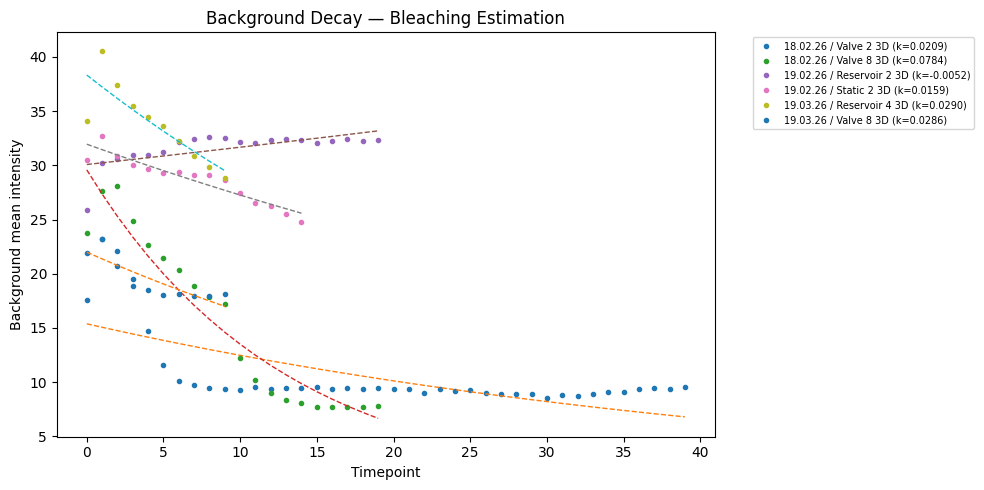

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# BLEACHING COEFFICIENTS: Fit exponential decay to background regions,
# add correction columns to all three DataFrames, and re-save CSVs.
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from scipy.optimize import curve_fit

def _exp_decay(t, a, k):
    return a * np.exp(-k * t)

bleach_coefficients = {}

for condition, paths in sorted(groups.items()):
    bg_means = []
    bg_mask = None

    for p in paths:
        data = tifffile.imread(str(p))
        if data.ndim != 4:
            continue
        for t in range(data.shape[0]):
            frame_maxz = data[t].max(axis=0)
            if bg_mask is None:
                thresh = threshold_otsu(frame_maxz)
                bg_mask = frame_maxz < thresh
            bg_means.append(float(frame_maxz[bg_mask].mean()))

    bg_mask = None
    bg_means = np.array(bg_means)
    timepoints = np.arange(len(bg_means))

    if len(bg_means) == 0:
        print(f"  SKIP {condition}: no 4D data found")
        bleach_coefficients[condition] = {"k": 0.0, "a": 0.0, "bg_means": bg_means, "correction": np.array([])}
        continue

    try:
        popt, _ = curve_fit(_exp_decay, timepoints, bg_means,
                            p0=[bg_means[0], 0.01], maxfev=10000)
        a_fit, k_fit = popt
        fitted = _exp_decay(timepoints, a_fit, k_fit)
        correction = fitted[0] / fitted
    except Exception:
        k_fit, a_fit = 0.0, float(bg_means[0])
        correction = np.ones(len(bg_means))

    bleach_coefficients[condition] = {
        "k": k_fit, "a": a_fit,
        "bg_means": bg_means, "correction": correction,
    }
    print(f"{condition}: k={k_fit:.6f}, half-life={np.log(2)/max(k_fit,1e-12):.1f} frames, n={len(bg_means)}")

# ── Apply correction to all DataFrames ───────────────────────────────────────
for _df, label in [(df, "all-Z"), (df_mid, "mid-3"), (df_bg, "BG-removed")]:
    _df["bleach_k"] = _df["condition"].map(lambda c: bleach_coefficients[c]["k"])
    _df["correction_factor"] = 1.0
    _df["corrected_intensity"] = _df["sum_intensity"]
    for cond, info in bleach_coefficients.items():
        mask = _df["condition"] == cond
        n = mask.sum()
        _df.loc[mask, "correction_factor"] = info["correction"][:n]
    _df["corrected_intensity"] = (_df["sum_intensity"] * _df["correction_factor"]).astype(int)
    print(f"  Added correction to {label} ({len(_df)} rows)")

# ── Save all CSVs ────────────────────────────────────────────────────────────
df.to_csv(root / "sum_intensity_per_timepoint.csv", index=False)
df_mid.to_csv(root / "sum_intensity_middle3_slices.csv", index=False)
df_bg.to_csv(root / "sum_intensity_bg_removed.csv", index=False)
print("\nCSVs saved.")

# ── Plot background decay + fits ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for condition, info in sorted(bleach_coefficients.items()):
    if len(info["bg_means"]) == 0:
        continue
    tp = np.arange(len(info["bg_means"]))
    ax.plot(tp, info["bg_means"], "o", markersize=3, label=f"{condition} (k={info['k']:.4f})")
    ax.plot(tp, _exp_decay(tp, info["a"], info["k"]), "--", lw=1)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Background mean intensity")
ax.set_title("Background Decay — Bleaching Estimation")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(str(root / "bleaching_decay_fits.png"), dpi=150, bbox_inches="tight")
plt.show()

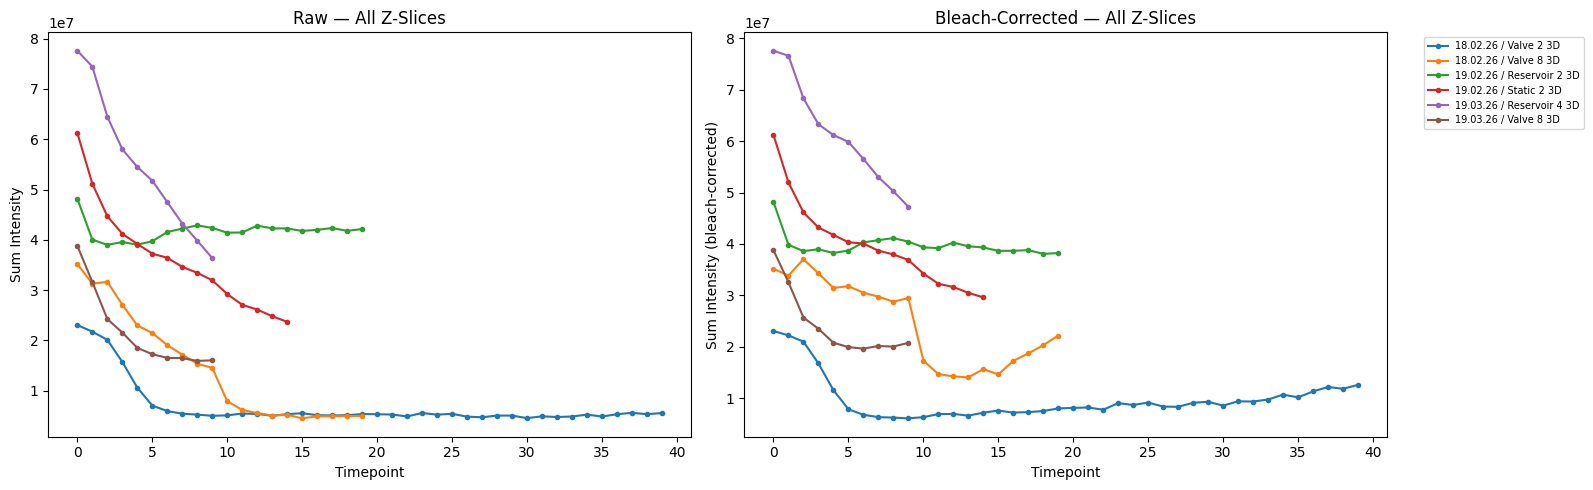

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT: All Z-slices — raw vs bleach-corrected
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for condition, grp in df.groupby("condition"):
    tp = grp["timepoint"].values
    axes[0].plot(tp, grp["sum_intensity"].values, marker="o", markersize=3, label=condition)
    axes[1].plot(tp, grp["corrected_intensity"].values, marker="o", markersize=3, label=condition)

axes[0].set_xlabel("Timepoint"); axes[0].set_ylabel("Sum Intensity")
axes[0].set_title("Raw — All Z-Slices")
axes[1].set_xlabel("Timepoint"); axes[1].set_ylabel("Sum Intensity (bleach-corrected)")
axes[1].set_title("Bleach-Corrected — All Z-Slices")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(str(root / "plot_all_z_raw_vs_corrected.png"), dpi=150, bbox_inches="tight")
plt.show()

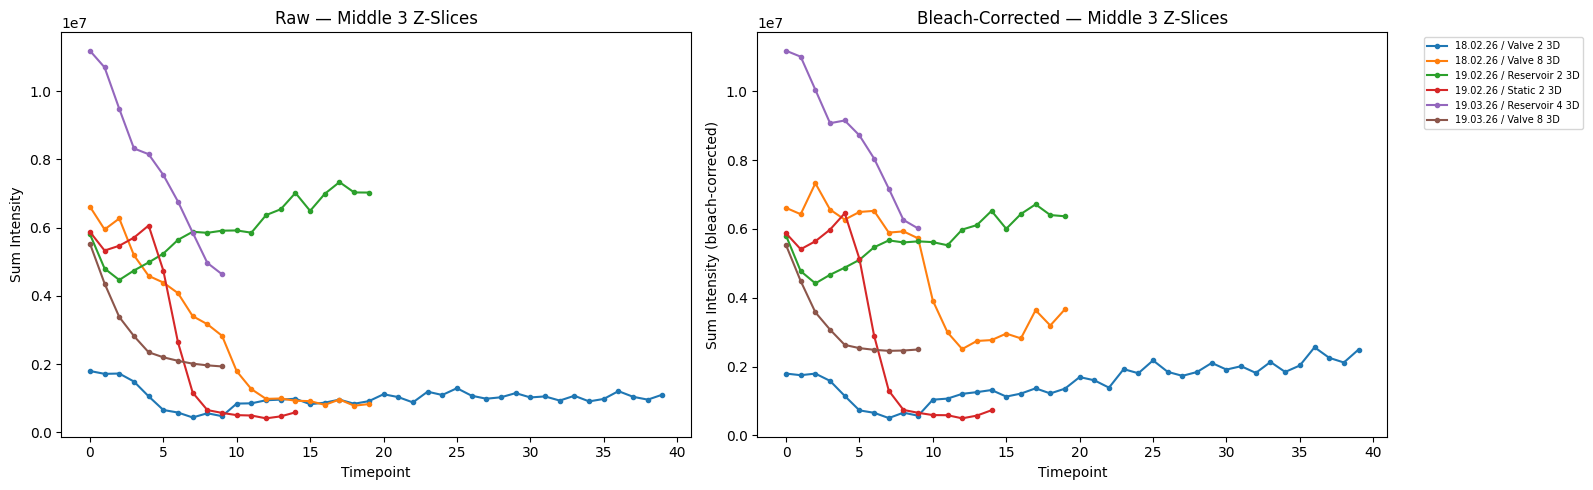

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT: Middle 3 Z-slices — raw vs bleach-corrected
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for condition, grp in df_mid.groupby("condition"):
    tp = grp["timepoint"].values
    axes[0].plot(tp, grp["sum_intensity"].values, marker="o", markersize=3, label=condition)
    axes[1].plot(tp, grp["corrected_intensity"].values, marker="o", markersize=3, label=condition)

axes[0].set_xlabel("Timepoint"); axes[0].set_ylabel("Sum Intensity")
axes[0].set_title("Raw — Middle 3 Z-Slices")
axes[1].set_xlabel("Timepoint"); axes[1].set_ylabel("Sum Intensity (bleach-corrected)")
axes[1].set_title("Bleach-Corrected — Middle 3 Z-Slices")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(str(root / "plot_middle3_raw_vs_corrected.png"), dpi=150, bbox_inches="tight")
plt.show()

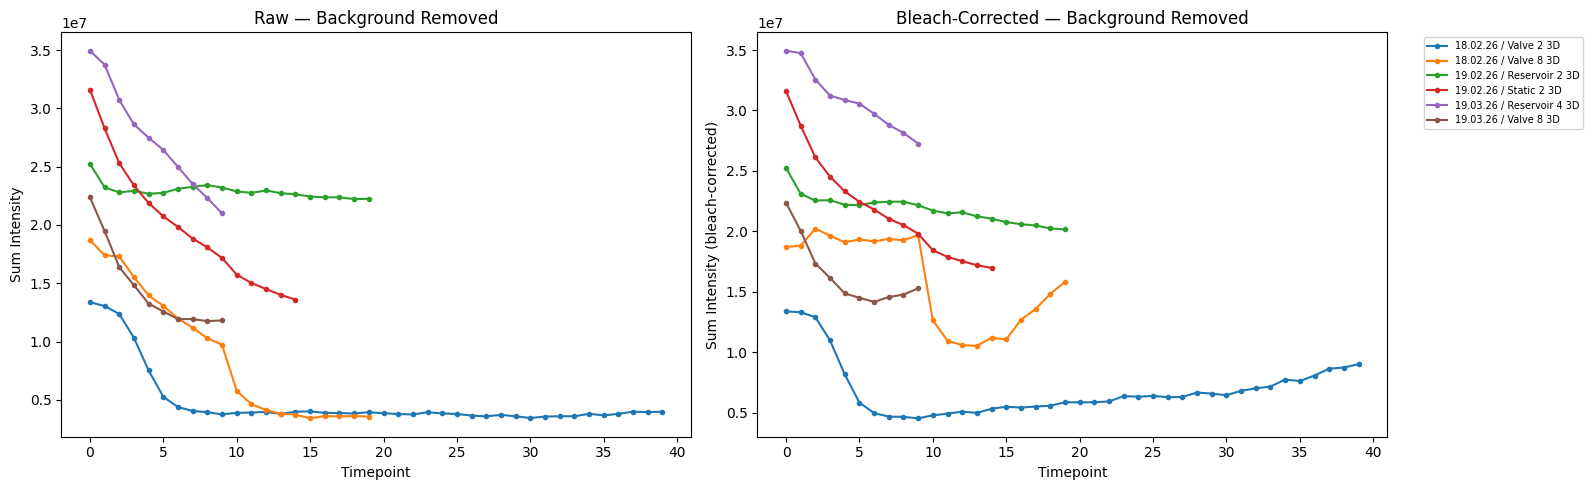

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT: Background-removed — raw vs bleach-corrected
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for condition, grp in df_bg.groupby("condition"):
    tp = grp["timepoint"].values
    axes[0].plot(tp, grp["sum_intensity"].values, marker="o", markersize=3, label=condition)
    axes[1].plot(tp, grp["corrected_intensity"].values, marker="o", markersize=3, label=condition)

axes[0].set_xlabel("Timepoint"); axes[0].set_ylabel("Sum Intensity")
axes[0].set_title("Raw — Background Removed")
axes[1].set_xlabel("Timepoint"); axes[1].set_ylabel("Sum Intensity (bleach-corrected)")
axes[1].set_title("Bleach-Corrected — Background Removed")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(str(root / "plot_bg_removed_raw_vs_corrected.png"), dpi=150, bbox_inches="tight")
plt.show()